In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Data extraction
import zipfile
with zipfile.ZipFile('Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset_folder')
print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os
print(os.listdir("dataset_folder"))

['Dataset']


In [4]:
#trying to extract the raw data
for root, dirs, files in os.walk("dataset_folder"):
    print(root)

dataset_folder
dataset_folder/Dataset
dataset_folder/Dataset/handwriting-collector
dataset_folder/Dataset/handwriting-collector/.git
dataset_folder/Dataset/handwriting-collector/.git/objects
dataset_folder/Dataset/handwriting-collector/.git/objects/info
dataset_folder/Dataset/handwriting-collector/.git/objects/pack
dataset_folder/Dataset/handwriting-collector/.git/refs
dataset_folder/Dataset/handwriting-collector/.git/refs/remotes
dataset_folder/Dataset/handwriting-collector/.git/refs/remotes/origin
dataset_folder/Dataset/handwriting-collector/.git/refs/heads
dataset_folder/Dataset/handwriting-collector/.git/refs/tags
dataset_folder/Dataset/handwriting-collector/.git/hooks
dataset_folder/Dataset/handwriting-collector/.git/info
dataset_folder/Dataset/handwriting-collector/.git/logs
dataset_folder/Dataset/handwriting-collector/.git/logs/refs
dataset_folder/Dataset/handwriting-collector/.git/logs/refs/remotes
dataset_folder/Dataset/handwriting-collector/.git/logs/refs/remotes/origin
datas

In [5]:
base_path = "dataset_folder/Dataset/handwriting-collector/dataset"

In [6]:
#importing
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [7]:
#image loading and preprocessing
data = []
labels = []

IMG_SIZE = 28
for label in os.listdir(base_path):
    folder_path = os.path.join(base_path, label)

    # Skip non-folders
    if not os.path.isdir(folder_path):
        continue
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        # Read grayscale image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        # Skip broken images
        if img is None:
            continue
        # Resize image
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(label)
print("Total images loaded:", len(data))

Total images loaded: 1612


In [8]:
data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (1612, 28, 28)
Labels shape: (1612,)


In [9]:
#normalization
data = data / 255.0

In [10]:
#label encoding
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
print("Classes:", le.classes_)

Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [11]:
#reshaping data for cnn
data = data.reshape(-1, 28, 28, 1)
print(data.shape)

(1612, 28, 28, 1)


In [12]:
#Stratified train/validation/test split
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [14]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1031, 28, 28, 1)
Validation: (258, 28, 28, 1)
Test: (323, 28, 28, 1)


**Model-1: Building CNN from Scratch**

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [16]:
# building first cnnmodel
model1 = Sequential([
    tf.keras.Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),

    Dense(128, activation='relu'),
    Dense(26, activation='softmax')
])

In [17]:
#compile the model
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
#augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

In [19]:
#training the model
history1 = model1.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=15
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.0349 - loss: 3.2633 - val_accuracy: 0.0659 - val_loss: 3.2429
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0737 - loss: 3.2136 - val_accuracy: 0.1357 - val_loss: 3.0761
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1668 - loss: 2.9502 - val_accuracy: 0.3333 - val_loss: 2.4132
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3240 - loss: 2.3167 - val_accuracy: 0.4806 - val_loss: 1.8150
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4423 - loss: 1.8632 - val_accuracy: 0.5659 - val_loss: 1.5008
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5742 - loss: 1.5012 - val_accuracy: 0.6202 - val_loss: 1.2223
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6111 - loss: 1.3186 - val_accuracy: 0.6705 - val_loss: 1.0837
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6508 - loss: 1.1423 - val_accuracy: 0.6124 - 

In [20]:
#evaluating the model
test_loss, test_accuracy = model1.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8545 - loss: 0.4964
Test Accuracy: 0.8544891476631165


In [21]:
test_loss, model1_acc = model1.evaluate(X_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8545 - loss: 0.4964


**Making CNN model-2 (Improved+regularized)**

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# MODEL 2
model2 = Sequential([
    tf.keras.Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(26, activation='softmax')
])
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)
test_loss, test_acc = model2.evaluate(X_test, y_test)
print("Model 2 Test Accuracy:", test_acc)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - accuracy: 0.2241 - loss: 2.9888 - val_accuracy: 0.0388 - val_loss: 3.4223
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5509 - loss: 1.5727 - val_accuracy: 0.0388 - val_loss: 4.2702
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7022 - loss: 1.0187 - val_accuracy: 0.0388 - val_loss: 5.3387
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7692 - loss: 0.7566 - val_accuracy: 0.0388 - val_loss: 6.3590
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8332 - loss: 0.5377 - val_accuracy: 0.0388 - val_loss: 7.3811
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8943 - loss: 0.4062 - val_accuracy: 0.0388 - val_loss: 7.7161
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9059 - loss: 0.3136 - val_accuracy: 0.0388 - val_loss: 8.2051
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9370 - loss: 0.2366 - val_accuracy: 0.0465 - val_lo

In [23]:
test_loss, model2_acc = model2.evaluate(X_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2539 - loss: 3.3650 


**CNN Model-3 (different optimization strategy)**

In [24]:
# MODEL 3
model3 = Sequential([
    tf.keras.Input(shape=(28,28,1)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(26, activation='softmax')
])
model3.compile(
    optimizer='rmsprop',   # key difference
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,   # different training behavior
    batch_size=64  # changed batch size
)
test_loss, test_acc = model3.evaluate(X_test, y_test)
print("Model 3 Test Accuracy:", test_acc)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.0572 - loss: 3.2678 - val_accuracy: 0.0388 - val_loss: 3.2338
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1261 - loss: 3.0577 - val_accuracy: 0.1434 - val_loss: 2.9421
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3269 - loss: 2.3699 - val_accuracy: 0.3101 - val_loss: 2.2966
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4791 - loss: 1.8336 - val_accuracy: 0.2946 - val_loss: 2.2172
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5674 - loss: 1.4638 - val_accuracy: 0.5000 - val_loss: 1.7067
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6382 - loss: 1.2349 - val_accuracy: 0.6240 - val_loss: 1.3124
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7245 - loss: 0.9346 - val_accuracy: 0.5853 - val_loss: 1.4207
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7721 - loss: 0.8073 - val_accuracy: 0.5116 - val_lo

In [25]:
test_loss, model3_acc = model3.evaluate(X_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7895 - loss: 0.8585 


**Model-4: Transfer Learning Model — MobileNetV2**
(as it uses 3-channel rgb images of (224x224) but as our dataset is of grayscale and (28x28) hence we would be changing that to let the model adapt properly)

In [26]:
#resize + convert to 3 channels
import tensorflow as tf
import numpy as np

# Resize from 28x28 → 224x224 and convert grayscale → RGB
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb   = np.repeat(X_val, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)

X_train_rgb = tf.image.resize(X_train_rgb, (224, 224))
X_val_rgb   = tf.image.resize(X_val_rgb, (224, 224))
X_test_rgb  = tf.image.resize(X_test_rgb, (224, 224))

In [27]:
#load MobileNetV2 Base Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [28]:
#building transfer lwarning model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
#adding custome classifier header
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(26, activation='softmax')(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

In [30]:
#compiling the model
model_mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
#training the model
history_mn = model_mobilenet.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 50s 960ms/step - accuracy: 0.2473 - loss: 2.7268 - val_accuracy: 0.6589 - val_loss: 1.6256
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5131 - loss: 1.6398 - val_accuracy: 0.7946 - val_loss: 0.9505
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6625 - loss: 1.1071 - val_accuracy: 0.8411 - val_loss: 0.6923
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7682 - loss: 0.8083 - val_accuracy: 0.8682 - val_loss: 0.5504
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8089 - loss: 0.6480 - val_accuracy: 0.8876 - val_loss: 0.4702
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8487 - loss: 0.5663 - val_accuracy: 0.9031 - val_loss: 0.3791
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8603 - loss: 0.4906 - val_accuracy: 0.8992 - val_loss: 0.3547
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8817 - loss: 0.4205 - val_accuracy: 0.9147 -

In [32]:
#evaluate
test_loss, test_acc = model_mobilenet.evaluate(X_test_rgb, y_test)
print("MobileNet Test Accuracy:", test_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9659 - loss: 0.2070
MobileNet Test Accuracy: 0.9659442901611328


In [33]:
test_loss, mobilenet_acc = model_mobilenet.evaluate(X_test_rgb, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9659 - loss: 0.2070


**Model-5: ResNet50 Model**

In [34]:
#prepare data same as MobileNetV2 Model
import tensorflow as tf
import numpy as np

# Convert grayscale → RGB (same as MobileNet)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb   = np.repeat(X_val, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)

# Resize → 224x224
X_train_rgb = tf.image.resize(X_train_rgb, (224, 224))
X_val_rgb   = tf.image.resize(X_val_rgb, (224, 224))
X_test_rgb  = tf.image.resize(X_test_rgb, (224, 224))

In [35]:
#load ResNet50 Base Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze backbone

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
#adding custome classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(26, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

In [37]:
#compiling the model
model_resnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
#train model
history_resnet = model_resnet.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 30s 494ms/step - accuracy: 0.0495 - loss: 3.3549 - val_accuracy: 0.0388 - val_loss: 3.2414
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.0485 - loss: 3.2484 - val_accuracy: 0.0659 - val_loss: 3.2322
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.0640 - loss: 3.2318 - val_accuracy: 0.0698 - val_loss: 3.2179
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.0446 - loss: 3.2179 - val_accuracy: 0.0504 - val_loss: 3.2022
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.0485 - loss: 3.2183 - val_accuracy: 0.0349 - val_loss: 3.1944
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.0446 - loss: 3.1871 - val_accuracy: 0.0659 - val_loss: 3.1713
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.0553 - loss: 3.1616 - val_accuracy: 0.0891 - val_loss: 3.1465
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.0660 - loss: 3.1439 - val_accuracy: 0

In [39]:
#evaluate model
test_loss, test_acc = model_resnet.evaluate(X_test_rgb, y_test)
print("ResNet50 Test Accuracy:", test_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 437ms/step - accuracy: 0.1362 - loss: 3.0527
ResNet50 Test Accuracy: 0.13622291386127472


In [40]:
test_loss, resnet_acc = model_resnet.evaluate(X_test_rgb, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.1362 - loss: 3.0527


**MODEL 6 — CNN + BatchNorm + Improved Stability**

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model6 = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(26, activation='softmax')
])

model6.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history6 = model6.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)

test_loss, test_acc = model6.evaluate(X_test, y_test)
print("Model 6 Test Accuracy:", test_acc)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.1853 - loss: 3.2936 - val_accuracy: 0.0736 - val_loss: 3.2007
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4248 - loss: 1.9574 - val_accuracy: 0.0504 - val_loss: 3.3739
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5926 - loss: 1.3141 - val_accuracy: 0.0388 - val_loss: 3.7952
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7216 - loss: 0.9371 - val_accuracy: 0.0465 - val_loss: 4.3273
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7468 - loss: 0.7424 - val_accuracy: 0.0775 - val_loss: 4.4396
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8458 - loss: 0.5006 - val_accuracy: 0.0620 - val_loss: 4.5421
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8885 - loss: 0.3791 - val_accuracy: 0.0465 - val_loss: 4.6092
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9098 - loss: 0.2931 - val_accuracy: 0.1008 - val_l

In [42]:
test_loss, model6_acc = model6.evaluate(X_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7028 - loss: 0.9320 


**MODEL 7 — CNN with SGD Optimizer (Key Comparison Model)**

In [43]:
from tensorflow.keras.optimizers import SGD

model7 = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(26, activation='softmax')
])

model7.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history7 = model7.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)

test_loss, test_acc = model7.evaluate(X_test, y_test)
print("Model 7 Test Accuracy:", test_acc)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.0320 - loss: 3.2674 - val_accuracy: 0.0543 - val_loss: 3.2500
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0524 - loss: 3.2508 - val_accuracy: 0.1163 - val_loss: 3.2361
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0844 - loss: 3.2251 - val_accuracy: 0.1395 - val_loss: 3.1961
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1280 - loss: 3.1523 - val_accuracy: 0.2016 - val_loss: 3.0696
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2105 - loss: 2.9341 - val_accuracy: 0.2558 - val_loss: 2.6646
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2784 - loss: 2.4608 - val_accuracy: 0.3992 - val_loss: 2.1834
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4190 - loss: 1.8935 - val_accuracy: 0.5465 - val_loss: 1.6449
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5383 - loss: 1.4940 - val_accuracy: 0.5969 - val_loss

In [44]:
test_loss, model7_acc = model7.evaluate(X_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7864 - loss: 0.7252 


**MODEL 8 — CNN with Smaller Batch Size (Training Behavior Change)**

In [45]:
model8 = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(26, activation='softmax')
])

model8.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history8 = model8.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16   # KEY CHANGE
)

test_loss, test_acc = model8.evaluate(X_test, y_test)
print("Model 8 Test Accuracy:", test_acc)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.0533 - loss: 3.2466 - val_accuracy: 0.2016 - val_loss: 3.0840
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2144 - loss: 2.7274 - val_accuracy: 0.4302 - val_loss: 2.0751
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4161 - loss: 1.8984 - val_accuracy: 0.5969 - val_loss: 1.4442
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5839 - loss: 1.3452 - val_accuracy: 0.6860 - val_loss: 1.1742
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6790 - loss: 1.0295 - val_accuracy: 0.7209 - val_loss: 1.0249
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7682 - loss: 0.7628 - val_accuracy: 0.7403 - val_loss: 0.9636
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7963 - loss: 0.6279 - val_accuracy: 0.7248 - val_loss: 0.8816
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8244 - loss: 0.5164 - val_accuracy: 0.7674 - val_loss

In [46]:
test_loss, model8_acc = model8.evaluate(X_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8731 - loss: 0.4365 


**MODEL 9 — CNN with Data Augmentation (Final Improved Model)**

In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

model9 = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(26, activation='softmax')
])

model9.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history9 = model9.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=15
)

test_loss, test_acc = model9.evaluate(X_test, y_test)
print("Model 9 Test Accuracy:", test_acc)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.0281 - loss: 3.2727 - val_accuracy: 0.0504 - val_loss: 3.2548
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0369 - loss: 3.2560 - val_accuracy: 0.0581 - val_loss: 3.2473
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0621 - loss: 3.2386 - val_accuracy: 0.0853 - val_loss: 3.1887
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0960 - loss: 3.1728 - val_accuracy: 0.2016 - val_loss: 3.0031
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1474 - loss: 3.0000 - val_accuracy: 0.2752 - val_loss: 2.6886
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1930 - loss: 2.7629 - val_accuracy: 0.4496 - val_loss: 2.2848
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2696 - loss: 2.4756 - val_accuracy: 0.5000 - val_loss: 1.8872
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3201 - loss: 2.2448 - val_accuracy: 0.5581 - 

In [48]:
test_loss, model9_acc = model9.evaluate(X_test, y_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8235 - loss: 0.7362 


In [49]:
import pandas as pd

df = pd.DataFrame({
    "Model": [
        "CNN Model 1",
        "CNN Model 2",
        "CNN Model 3",
        "MobileNetV2",
        "ResNet50",
        "CNN Model 6",
        "CNN Model 7",
        "CNN Model 8",
        "CNN Model 9"
    ],
    "Test Accuracy": [
        0.8514,
        0.3467,
        0.8111,
        0.9505,
        0.1486,
        0.7090,
        0.7740,
        0.8793,
        0.8607
    ]
})

df

,Model,Test Accuracy
0,CNN Model 1,0.8514
1,CNN Model 2,0.3467
2,CNN Model 3,0.8111
3,MobileNetV2,0.9505
4,ResNet50,0.1486
5,CNN Model 6,0.7090
6,CNN Model 7,0.7740
7,CNN Model 8,0.8793
8,CNN Model 9,0.8607


**Sorting them from best to worst on the basis of accuracy**

In [50]:
df_sorted = df.sort_values(by="Test Accuracy", ascending=False)
df_sorted

,Model,Test Accuracy
3,MobileNetV2,0.9505
7,CNN Model 8,0.8793
8,CNN Model 9,0.8607
0,CNN Model 1,0.8514
2,CNN Model 3,0.8111
6,CNN Model 7,0.7740
5,CNN Model 6,0.7090
1,CNN Model 2,0.3467
4,ResNet50,0.1486


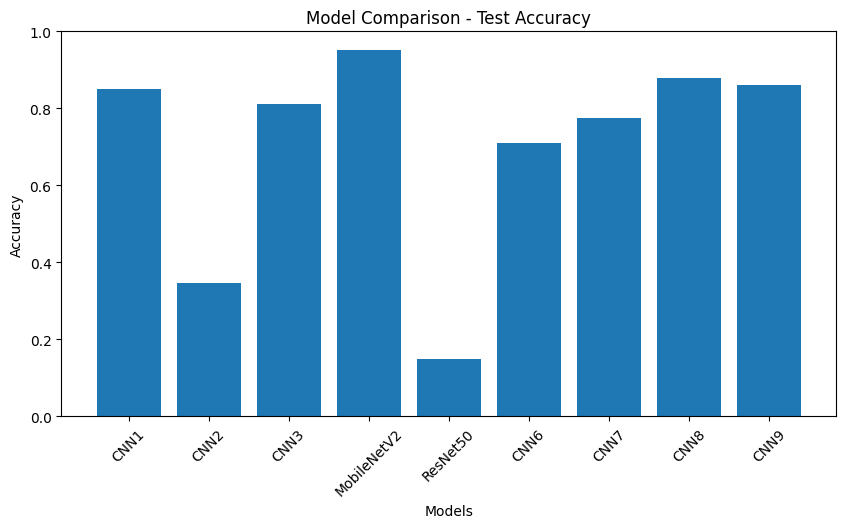

In [51]:
#accuracy comparision graph
import matplotlib.pyplot as plt

models = [
    "CNN1", "CNN2", "CNN3",
    "MobileNetV2", "ResNet50",
    "CNN6", "CNN7", "CNN8", "CNN9"
]

accuracy = [
    0.8514,
    0.3467,
    0.8111,
    0.9505,
    0.1486,
    0.7090,
    0.7740,
    0.8793,
    0.8607
]

plt.figure(figsize=(10,5))
plt.bar(models, accuracy)

plt.title("Model Comparison - Test Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.show()

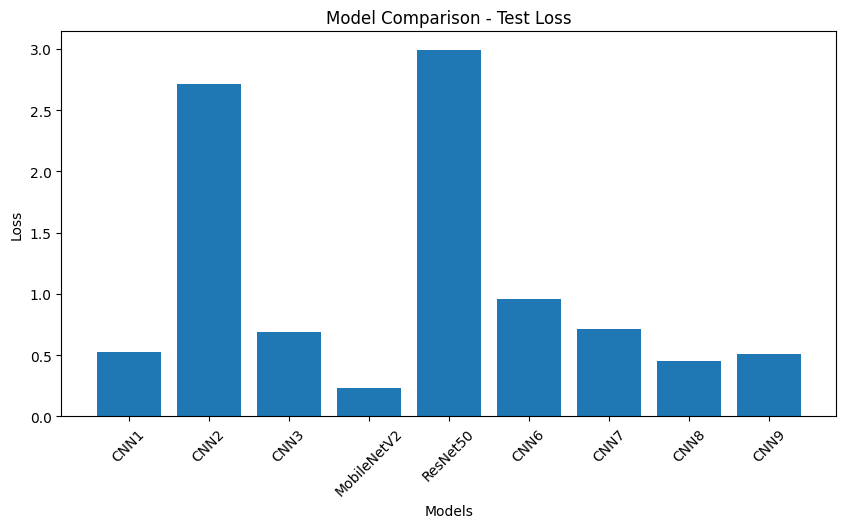

In [52]:
#loss comaprision Graph
loss = [
    0.5272,
    2.7143,
    0.6923,
    0.2312,
    2.9932,
    0.9557,
    0.7152,
    0.4493,
    0.5115
]

plt.figure(figsize=(10,5))
plt.bar(models, loss)

plt.title("Model Comparison - Test Loss")
plt.xlabel("Models")
plt.ylabel("Loss")
plt.xticks(rotation=45)

plt.show()

Split Ratio Experiment - ON MODEL 9

In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [54]:
# data already: (28,28,1)
# labels_encoded already ready
print(data.shape)
print(labels_encoded.shape)

(1612, 28, 28, 1)
(1612,)


SPLIT 1 (80-10-10)

In [55]:
X_train1, X_temp1, y_train1, y_temp1 = train_test_split(
    data, labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

X_val1, X_test1, y_val1, y_test1 = train_test_split(
    X_temp1, y_temp1,
    test_size=0.5,
    random_state=42,
    stratify=y_temp1
)

print("Split 1:", X_train1.shape, X_val1.shape, X_test1.shape)

Split 1: (1289, 28, 28, 1) (161, 28, 28, 1) (162, 28, 28, 1)


In [56]:
model_split1 = tf.keras.models.clone_model(model9)

model_split1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model_split1.fit(
    X_train1, y_train1,
    validation_data=(X_val1, y_val1),
    epochs=10,
    batch_size=32
)

loss1, acc1 = model_split1.evaluate(X_test1, y_test1)
print("Split 1 Accuracy:", acc1)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.0543 - loss: 3.2567 - val_accuracy: 0.0745 - val_loss: 3.2070
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1024 - loss: 3.1147 - val_accuracy: 0.3292 - val_loss: 2.7764
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2506 - loss: 2.5592 - val_accuracy: 0.5217 - val_loss: 1.9648
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4445 - loss: 1.9783 - val_accuracy: 0.6025 - val_loss: 1.4524
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5097 - loss: 1.6015 - val_accuracy: 0.6584 - val_loss: 1.1708
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6036 - loss: 1.3381 - val_accuracy: 0.7516 - val_loss: 0.9842
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6493 - loss: 1.1447 - val_accuracy: 0.7640 - val_loss: 0.8553
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7005 - loss: 0.9586 - val_accuracy: 0.7702 - val_loss

SPLIT 2 (70-15-15)

In [57]:
X_train2, X_temp2, y_train2, y_temp2 = train_test_split(
    data, labels_encoded,
    test_size=0.3,
    random_state=42,
    stratify=labels_encoded
)

X_val2, X_test2, y_val2, y_test2 = train_test_split(
    X_temp2, y_temp2,
    test_size=0.5,
    random_state=42,
    stratify=y_temp2
)

print("Split 2:", X_train2.shape, X_val2.shape, X_test2.shape)

Split 2: (1128, 28, 28, 1) (242, 28, 28, 1) (242, 28, 28, 1)


In [58]:
model_split2 = tf.keras.models.clone_model(model9)

model_split2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model_split2.fit(
    X_train2, y_train2,
    validation_data=(X_val2, y_val2),
    epochs=10,
    batch_size=32
)

loss2, acc2 = model_split2.evaluate(X_test2, y_test2)
print("Split 2 Accuracy:", acc2)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.0550 - loss: 3.2417 - val_accuracy: 0.1570 - val_loss: 3.1601
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1410 - loss: 3.0047 - val_accuracy: 0.3512 - val_loss: 2.6584
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2775 - loss: 2.4714 - val_accuracy: 0.5083 - val_loss: 1.9287
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4335 - loss: 1.8962 - val_accuracy: 0.6198 - val_loss: 1.4643
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5266 - loss: 1.5743 - val_accuracy: 0.6983 - val_loss: 1.1398
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6144 - loss: 1.2754 - val_accuracy: 0.7603 - val_loss: 0.9590
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6569 - loss: 1.1191 - val_accuracy: 0.7686 - val_loss: 0.8625
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7101 - loss: 0.9606 - val_accuracy: 0.7893 - val_los

FINAL COMAPRISION TABLE

In [59]:
df_split = pd.DataFrame({
    "Split Ratio": ["80-10-10", "70-15-15"],
    "Test Accuracy": [acc1, acc2]
})

df_split

,Split Ratio,Test Accuracy
0,80-10-10,0.808642
1,70-15-15,0.814050


PLOTTED A GRAPH TO VISUALIZE THE COMPARISION

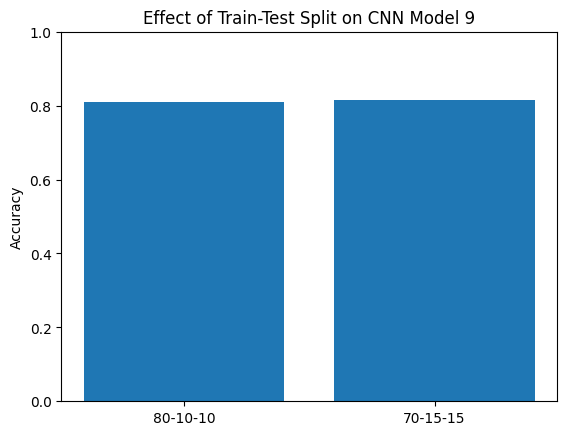

In [60]:
import matplotlib.pyplot as plt

plt.bar(df_split["Split Ratio"], df_split["Test Accuracy"])
plt.title("Effect of Train-Test Split on CNN Model 9")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

**INTERACTIVE PREDICTION SYSTEM**

Saving user_0e2f0c_I.png to user_0e2f0c_I (3).png
Saving user_4b349c_A.png to user_4b349c_A (3).png
Saving user_4e55ae_B.png to user_4e55ae_B (3).png
Saving user_4e55ae_C.png to user_4e55ae_C (3).png
Saving user_4e55ae_D.png to user_4e55ae_D (3).png
Saving user_4e55ae_E.png to user_4e55ae_E (3).png
Saving user_4e55ae_F.png to user_4e55ae_F (4).png
Saving user_4e55ae_G.png to user_4e55ae_G (3).png
Saving user_4e55ae_H.png to user_4e55ae_H (3).png
Saving user_4e55ae_K.png to user_4e55ae_K (1).png
Saving user_4e55ae_O.png to user_4e55ae_O (1).png
Saving user_4e55ae_R.png to user_4e55ae_R (1).png
Saving user_4e55ae_X.png to user_4e55ae_X (1).png


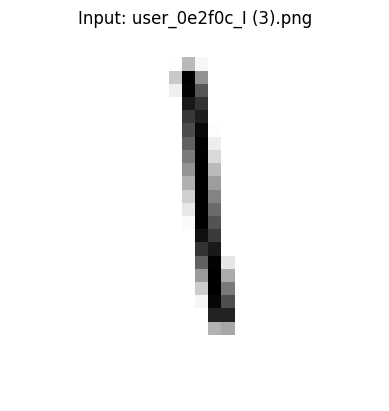

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
 Predicted Letter: Y
 Confidence: 0.31
----------------------------------------


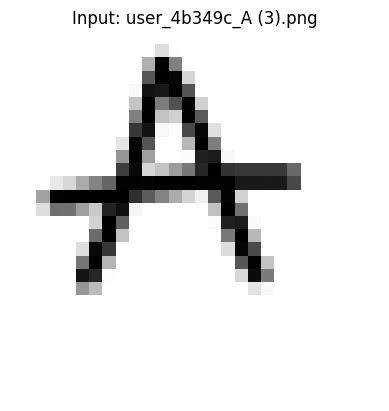

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
 Predicted Letter: A
 Confidence: 0.82
----------------------------------------


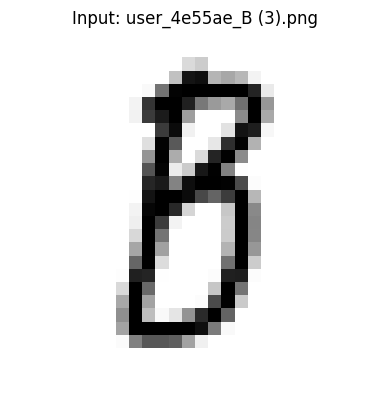

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
 Predicted Letter: B
 Confidence: 0.68
----------------------------------------


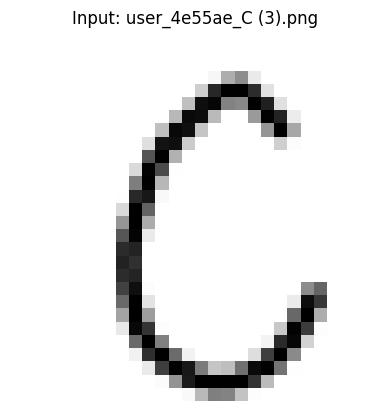

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
 Predicted Letter: C
 Confidence: 0.25
----------------------------------------


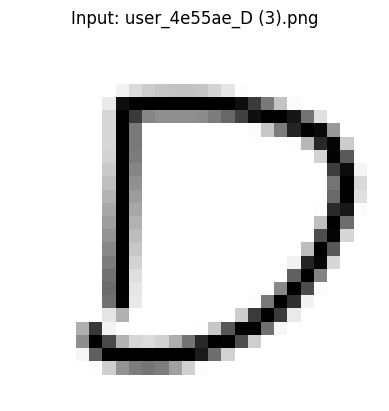

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
 Predicted Letter: D
 Confidence: 0.49
----------------------------------------


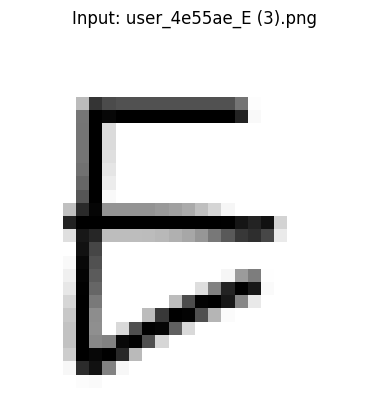

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
 Predicted Letter: E
 Confidence: 0.71
----------------------------------------


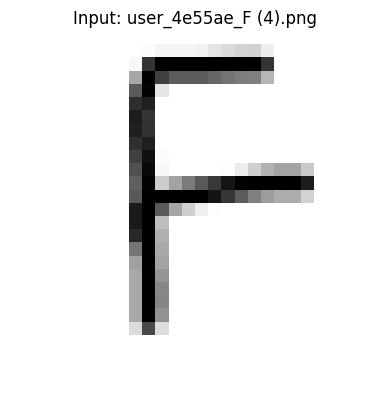

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
 Predicted Letter: F
 Confidence: 0.96
----------------------------------------


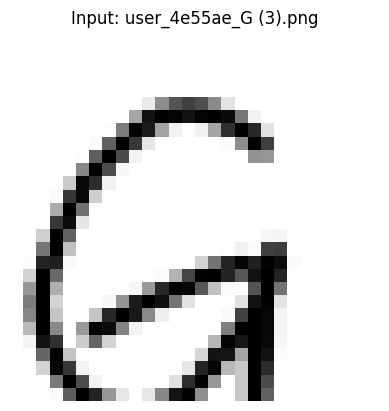

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
 Predicted Letter: Q
 Confidence: 0.45
----------------------------------------


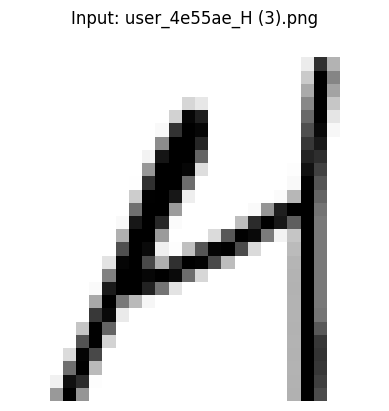

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
 Predicted Letter: B
 Confidence: 0.40
----------------------------------------


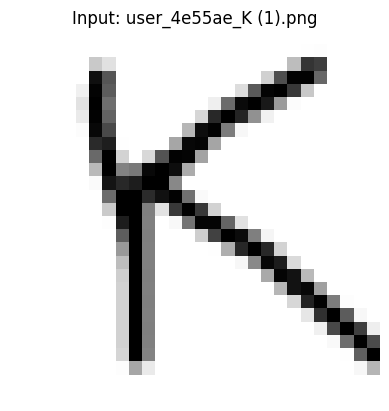

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
 Predicted Letter: X
 Confidence: 0.56
----------------------------------------


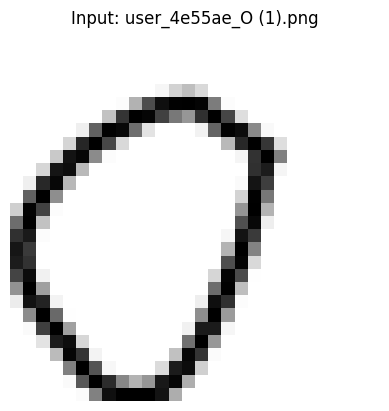

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
 Predicted Letter: D
 Confidence: 0.42
----------------------------------------


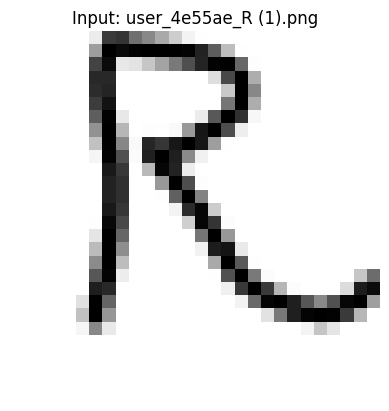

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
 Predicted Letter: R
 Confidence: 0.35
----------------------------------------


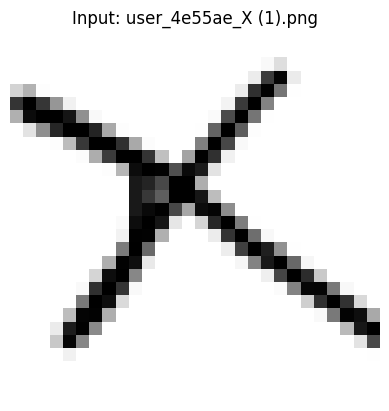

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
 Predicted Letter: X
 Confidence: 0.93
----------------------------------------


In [71]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload multiple images
uploaded = files.upload()
results = []

for img_name in uploaded.keys():

    # Read image
    img = cv2.imread(img_name, cv2.IMREAD_GRAYSCALE)

    # Show original image
    plt.imshow(img, cmap='gray')
    plt.title(f"Input: {img_name}")
    plt.axis("off")
    plt.show()

    # Preprocessing
    img_resized = cv2.resize(img, (28, 28))
    img_resized = img_resized / 255.0
    img_input = img_resized.reshape(1, 28, 28, 1)

    # Prediction
    pred = model9.predict(img_input)

    class_index = np.argmax(pred)
    letter = le.inverse_transform([class_index])[0]

    confidence = np.max(pred)

    # Show result
    print(f" Predicted Letter: {letter}")
    print(f" Confidence: {confidence:.2f}")
    print("-" * 40)

    # store results
    results.append((img_name, letter, confidence))